$$
\textbf{Nome: Gabriel Souza Almeida. } \\
\textbf{Matrícula: 2026010096}
$$

$$
\textbf{Nome: Valderi Alves de Souza Neto. } \\
\textbf{Matrícula: 2026010167}
$$

In [1]:
import pandas as pd
  
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')

df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


# 1 - Recodificando e importância da normalização:

- Importância da normalização:
O k-NN calcula a distância entre amostras para determinar quais são as mais próximas. Por isso, atributos com escalas muito diferentes dominam esse cálculo, por exemplo, total sulfur dioxide pode chegar a 289, enquanto pH fica entre 3,0 e 4,0. Sem normalização, o modelo passaria a tomar decisões quase que exclusivamente com base nos atributos de maior magnitude, ignorando os demais. A normalização Min-Max transforma todos os atributos para o intervalo entre 0 e 1, garantindo que cada variável contribua de forma equilibrada para o cálculo da distância.

In [2]:
from sklearn.preprocessing import MinMaxScaler

# RECODIFICANDO QUALITY
def classificar(q):
    if q <= 5:
        return 'ruim'
    elif q <= 7:
        return 'medio'
    else:
        return 'bom'

df['quality'] = df['quality'].apply(classificar)

# NORMALIZANDO
X = df.drop(columns=["quality"])

y = df["quality"]

scaler  = MinMaxScaler(feature_range=(0, 1))
scaled  = scaler.fit_transform(X)
df_scaled = pd.DataFrame(scaled, columns=X.columns)
X = df_scaled

# 2 - Treino e teste:

In [3]:
from sklearn.model_selection import train_test_split

#Dividindo treinamento
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

# 3 - Treinamento e escolha do K:

- K escolhido:
Testando valores de k de 1 a 21 com validação cruzada de 5 folds, o maior valor de acurácia média foi obtido em k = 17 (0.7178). Por isso esse foi o valor escolhido para treinar o modelo final.
- Valores baixos e altos:
Para valores muito baixos de k (ex: k = 1), o modelo fica extremamente sensível a ruído e outliers, cada ponto de treino tem influência total sobre a predição, levando a overfitting: o desempenho no treino é alto, mas o modelo generaliza mal para dados novos. Isso é visível no gráfico, onde k = 1 apresenta acurácia elevada mas isolada, seguida de uma queda abrupta.
Para valores muito altos de k, a vizinhança passa a incluir pontos de classes diferentes, suavizando demais as fronteiras de decisão. O modelo tende a prever sempre a classe majoritária, no caso deste dataset, "médio", prejudicando o reconhecimento das demais classes.

k= 1 | Acurácia média (CV): 0.7170
k= 3 | Acurácia média (CV): 0.6810
k= 5 | Acurácia média (CV): 0.6810
k= 7 | Acurácia média (CV): 0.6857
k=11 | Acurácia média (CV): 0.6998
k=13 | Acurácia média (CV): 0.7068
k=15 | Acurácia média (CV): 0.7162
k=17 | Acurácia média (CV): 0.7178
k=19 | Acurácia média (CV): 0.7146
k=21 | Acurácia média (CV): 0.7139


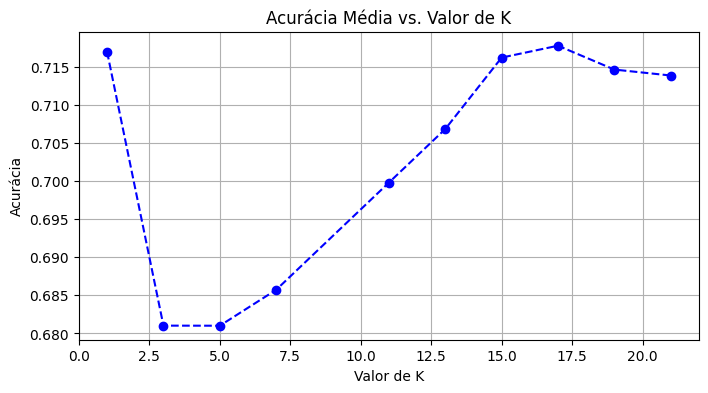

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

valores_k = [1, 3, 5, 7, 11, 13, 15, 17, 19, 21]
acuracias_medias = []

for k in valores_k:
    # 1. Instancia com o k da lista
    sklearn_knn = KNeighborsClassifier(n_neighbors=k)
    
    # 2. Faz a validação cruzada (5 folds) APENAS no treino
    scores = cross_val_score(sklearn_knn, X_train, y_train, cv=5)
    
    # 3. Calcula a média dos 5
    acuracia_media = scores.mean()
    acuracias_medias.append(acuracia_media)
    
    print(f"k={k:2d} | Acurácia média (CV): {acuracia_media:.4f}")

# 4. Plotando o gráfico (Exigido na Questão 3)
plt.figure(figsize=(8, 4))
plt.plot(valores_k, acuracias_medias, marker='o', linestyle='--', color='b')
plt.title('Acurácia Média vs. Valor de K')
plt.xlabel('Valor de K')
plt.ylabel('Acurácia')
plt.grid(True)
plt.show()

# 4 - Treinamento e teste e validação do modelo
Com k = 17, o modelo atingiu acurácia geral de 79,37% no conjunto de teste. 

Analisando por classe:
- bom: precision, recall e F1-score iguais a 0.00. O modelo não foi capaz de prever corretamente nenhuma amostra desta classe, pois ela possui apenas 4 exemplos no conjunto de teste, representação insuficiente para que o k-NN encontre vizinhos dessa categoria.
- medio: F1-score de 0.81, com recall de 0.84, o modelo identifica bem a classe majoritária.
- ruim: F1-score de 0.78, com precision de 0.81, desempenho sólido, mas com alguma confusão com "médio".

- *As maiores confusões ocorrem entre as classes médio e ruim, o que é esperado dado que a fronteira química entre vinhos de nota 5 e nota 6 é tênue. A classe bom é completamente ignorada pelo modelo devido ao severo desbalanceamento do dataset, vinhos com nota ≥ 8 representam menos de 4% das amostras totais.*

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sklearn_knn = KNeighborsClassifier(n_neighbors=17)
sklearn_knn.fit(X_train, y_train)
y_prev_sklearn = sklearn_knn.predict(X_test)
print(confusion_matrix(y_prev_sklearn, y_test))
print(f"Acurácia: {accuracy_score(y_test, y_prev_sklearn):.4f}")

classes = ['bom', 'medio', 'ruim']
print(classification_report(y_test, y_prev_sklearn, labels=classes, target_names=classes))

[[  0   0   0]
 [  4 141  36]
 [  0  26 113]]
Acurácia: 0.7937
              precision    recall  f1-score   support

         bom       0.00      0.00      0.00         4
       medio       0.78      0.84      0.81       167
        ruim       0.81      0.76      0.78       149

    accuracy                           0.79       320
   macro avg       0.53      0.53      0.53       320
weighted avg       0.79      0.79      0.79       320



C:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave